In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import roc_curve, auc, confusion_matrix, classification_report
from sklearn.utils import shuffle
from scipy.stats import ks_2samp

In [2]:
#STD_DIR = "Dataset_Preparation\STD_images_train"      # <-- set path to standard images folder
STD_DIR = "Dataset_Preparation\STD_images_train"
AMBE_DIR = "Dataset_Preparation\AmBe_images_train"    # <-- set path to AmBe images folder

IMG_SIZE = (128, 128)
VALIDATION_SPLIT = 0.2
SEED = 4267
BATCH_SIZE = 64


# Reproducibility
tf.random.set_seed(SEED)
np.random.seed(SEED)

In [3]:
def load_all_images(folder, img_size=(128,128)):
    """Load grayscale images from folder, normalize to [0,1], skip corrupted."""
    exts = ['*.png', '*.PNG', '*.jpg', '*.jpeg', '*.bmp', '*.gif']
    paths = []
    
    for e in exts:
        paths.extend(glob.glob(os.path.join(folder, e)))
        
    # --- THE FIX ---
    # Convert to a set to remove duplicates, then back to a sorted list
    paths = sorted(list(set(paths)))
    
    imgs = []
    for p in paths:
        try:
            im = Image.open(p).convert("L")  # grayscale
            im = im.resize(img_size, Image.BILINEAR)
            arr = np.array(im, dtype=np.float32) / 255.0  # scale to [0,1]
            imgs.append(arr[..., None])  # add channel dim
        except Exception as e:
            print(f"[load_all_images] skipping {p}: {e}")
            
    if len(imgs) == 0:
        raise RuntimeError(f"No images loaded from {folder}")
        
    return np.stack(imgs, axis=0)  # (N,H,W,1)

def normalize_per_image(x):
    """Per-image mean/std normalization (avoid division by zero)."""
    mean = np.mean(x, axis=(1,2,3), keepdims=True)
    std = np.std(x, axis=(1,2,3), keepdims=True)
    return (x - mean) / (std + 1e-6)



def visualize_grid(images, titles=None, ncol=5, figsize=(12,3), cmap="gray"):
    n = len(images)
    nrow = int(np.ceil(n / ncol))
    plt.figure(figsize=figsize)
    for i in range(n):
        plt.subplot(nrow, ncol, i+1)
        plt.imshow(images[i].squeeze(), cmap=cmap, vmin=0, vmax=1)
        plt.axis("off")
        if titles:
            plt.title(titles[i], fontsize=8)
    plt.tight_layout()
    plt.show()

Loading images...
Loaded 7375 standard images and 7362 AmBe images.
Sample standard images:


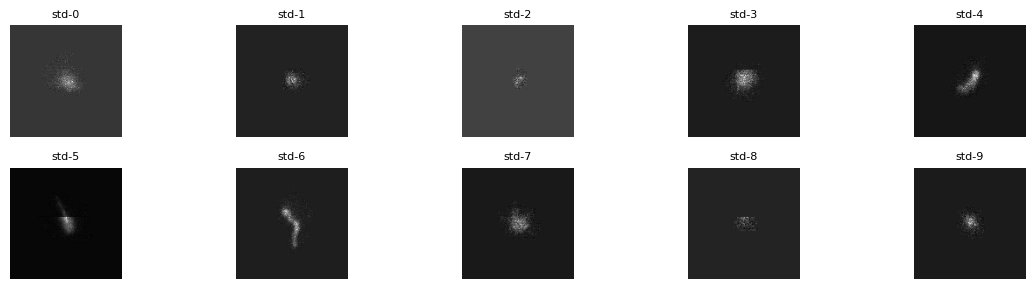

Sample AmBe images:


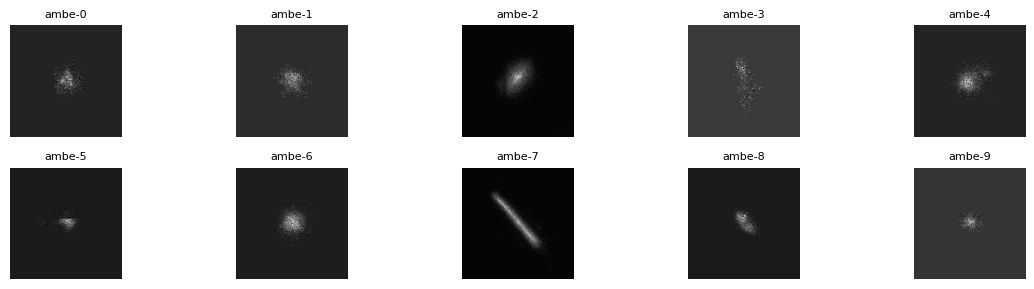

In [4]:
print("Loading images...") 
std_images = load_all_images(STD_DIR, img_size=IMG_SIZE)   # label 0
ambe_images = load_all_images(AMBE_DIR, img_size=IMG_SIZE) # label 1

print(f"Loaded {len(std_images)} standard images and {len(ambe_images)} AmBe images.")
print("Sample standard images:")
visualize_grid(std_images[:10], titles=[f"std-{i}" for i in range(10)], ncol=5)
print("Sample AmBe images:")
visualize_grid(ambe_images[:10], titles=[f"ambe-{i}" for i in range(10)], ncol=5)


In [5]:
import numpy as np
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import (
    BatchNorm, 
    SAGEConv, 
    global_max_pool, 
    global_mean_pool, 
    global_add_pool
)
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import roc_auc_score
import random
import os

# ==============================================================
# 1. GRAPH EXTRACTION & PREPROCESSING (NORMALIZED)
# ==============================================================
def estimate_pedestal(image):
    hist, edges = np.histogram(image, bins=256)
    mode_bin = np.argmax(hist)
    pedestal_value = (edges[mode_bin] + edges[mode_bin + 1]) / 2
    window_width = 20 
    mask_pedestal = np.abs(image - pedestal_value) <= window_width
    pedestal_sigma = np.std(image[mask_pedestal])
    return pedestal_value, pedestal_sigma

def convert_numpy_image_to_graph_CENTERED(img_array, k=5, min_nodes=50):
    img_2d = img_array.squeeze()
    
    # Sottrazione del background
    mode_val, sigma = estimate_pedestal(img_2d)
    threshold = mode_val + sigma
    y_coords, x_coords = np.where(img_2d > threshold)
    intensities = img_2d[y_coords, x_coords]
    
    num_nodes = len(intensities)
    if num_nodes < min_nodes or num_nodes < k + 1:
        return None, None

    # Normalizzazione Spaziale (Centrata e Scalata)
    x_centered = x_coords - np.mean(x_coords)
    y_centered = y_coords - np.mean(y_coords)
    x_norm = x_centered / 128.0
    y_norm = y_centered / 128.0
    
    # ---> FIX CRUCIALE: Normalizzazione dell'Intensità (Z-Score) <---
    # Senza questo, i valori grezzi degli ADC uccidono i gradienti della rete.
    # Normalizzando, evidenziamo i "picchi" relativi di energia (Bragg peaks)
    intensities_norm = (intensities - np.mean(intensities)) / (np.std(intensities) + 1e-6)
    
    nodes_features = np.column_stack((x_norm, y_norm, intensities_norm))
    x_tensor = torch.tensor(nodes_features, dtype=torch.float32)

    # Connessioni Spaziali (k=5)
    spatial_coords = np.column_stack((x_coords, y_coords))
    knn = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(spatial_coords)
    _, indices = knn.kneighbors(spatial_coords)
    
    source_nodes = np.repeat(np.arange(num_nodes), k)
    target_nodes = indices[:, 1:].flatten()
    
    edge_index_np = np.vstack((source_nodes, target_nodes))
    edge_index = torch.tensor(edge_index_np, dtype=torch.long)

    # Memorizziamo le features macroscopiche grezze per dopo (evita di ricalcolarle nel forward)
    # Scalate in logaritmo per stabilità matematica
    macro_features = torch.tensor([[
        np.log1p(num_nodes),               # log della lunghezza traccia
        np.log1p(np.sum(intensities))      # log dell'energia TOTALE grezza depositata
    ]], dtype=torch.float32)

    return x_tensor, edge_index, macro_features

def process_dataset(images_array, label_value, k=5):
    processed_graphs = []
    skipped_count = 0
    
    for i in range(len(images_array)):
        extracted = convert_numpy_image_to_graph_CENTERED(images_array[i], k=k)
        
        if extracted[0] is not None:
            x_tensor, edge_index, macro_features = extracted
            graph_data = Data(
                x=x_tensor,
                edge_index=edge_index,
                y=torch.tensor([[label_value]], dtype=torch.float32),
                macro_features=macro_features # Aggiungiamo la fisica qui!
            )
            processed_graphs.append(graph_data)
        else:
            skipped_count += 1
            
    if skipped_count > 0:
        print(f"Skipped {skipped_count} images (not enough active pixels).")
        
    return processed_graphs

C:\Users\Mattia\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
# ==============================================================
# 2. ARCHITECTURE (3-Layer SAGE + LeakyReLU + Macro Physics)
# ==============================================================
class CWolaGNN_Pro(torch.nn.Module):
    def __init__(self, num_node_features):
        super().__init__()
        
        # Aumentiamo la profondità a 3 Layer: il network ora vede fino a 3 "salti" di distanza.
        # Fondamentale per distinguere la topologia di tracce lunghe vs corte.
        self.conv1 = SAGEConv(num_node_features, 32)
        self.bn1 = BatchNorm(32)
        
        self.conv2 = SAGEConv(32, 64)
        self.bn2 = BatchNorm(64)
        
        self.conv3 = SAGEConv(64, 64)
        self.bn3 = BatchNorm(64)
        
        # Classifier: 64 (Max) + 64 (Mean) + 2 (Macro Physics passate dal Data loader) = 130
        self.classifier_hidden = torch.nn.Linear(130, 64)
        self.dropout = torch.nn.Dropout(p=0.5)
        self.classifier_out = torch.nn.Linear(64, 1)

    def forward(self, x, edge_index, batch, macro_features):
        # Usiamo LeakyReLU: previene il problema dei "neuroni morti" che causano previsioni piatte a 0.5
        
        # Layer 1
        h = self.conv1(x, edge_index)
        h = self.bn1(h)
        h = F.leaky_relu(h, negative_slope=0.1)

        # Layer 2
        h = self.conv2(h, edge_index)
        h = self.bn2(h)
        h = F.leaky_relu(h, negative_slope=0.1)
        
        # Layer 3 (Nuovo)
        h = self.conv3(h, edge_index)
        h = self.bn3(h)
        h = F.leaky_relu(h, negative_slope=0.1)

        # Multi-Pooling della topologia
        h_max = global_max_pool(h, batch)
        h_mean = global_mean_pool(h, batch)

        # Uniamo tutto: Topologia + Fisica Macroscopica pre-calcolata
        h_combined = torch.cat([h_max, h_mean, macro_features], dim=1)

        # Classificazione
        out = self.classifier_hidden(h_combined)
        out = F.leaky_relu(out, negative_slope=0.1)
        out = self.dropout(out)
        out = self.classifier_out(out)

        return out

# ==============================================================
# 3. DATA PREPARATION & TRAINING PIPELINE
# ==============================================================
if __name__ == "__main__":
    
    print("Extracting graphs from std_images (Label 0: ER)...")
    std_graphs = process_dataset(std_images, label_value=0.0, k=5)
    
    print("Extracting graphs from ambe_images (Label 1: ER + NR Mix)...")
    ambe_graphs = process_dataset(ambe_images, label_value=1.0, k=5)

    pyg_dataset = std_graphs + ambe_graphs
    random.seed(42)
    random.shuffle(pyg_dataset)

    split_idx = int(len(pyg_dataset) * 0.8)
    train_dataset = pyg_dataset[:split_idx]
    test_dataset = pyg_dataset[split_idx:]

    train_loader = PyGDataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = PyGDataLoader(test_dataset, batch_size=32, shuffle=False)

    print(f"Data ready! Train size: {len(train_dataset)}, Test size: {len(test_dataset)}\n")

    # Inizializziamo il modello aggiornato
    model = CWolaGNN_Pro(num_node_features=3)
    
    # FIX: Learning Rate abbassato (0.005 era troppo instabile e causava il blocco)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4) 
    criterion = torch.nn.BCEWithLogitsLoss()
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)

    def train():
        model.train()
        total_loss = 0
        all_preds = []
        all_labels = []
        
        for data in train_loader:
            optimizer.zero_grad()
            # Passiamo macro_features esplicitamente (calcolate durante l'estrazione)
            out = model(data.x, data.edge_index, data.batch, data.macro_features)
            loss = criterion(out.view(-1), data.y.view(-1))
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * data.num_graphs
            
            probs = torch.sigmoid(out.view(-1)).detach().cpu().numpy()
            all_preds.extend(probs)
            all_labels.extend(data.y.view(-1).cpu().numpy())
            
        try:
            auc = roc_auc_score(all_labels, all_preds)
        except ValueError:
            auc = 0.5 
            
        return total_loss / len(train_loader.dataset), auc

    def test():
        model.eval()
        total_loss = 0
        correct = 0
        total = 0
        all_preds = []
        all_labels = []
        
        with torch.no_grad():
            for data in test_loader:
                out = model(data.x, data.edge_index, data.batch, data.macro_features)
                
                loss = criterion(out.view(-1), data.y.view(-1))
                total_loss += loss.item() * data.num_graphs
                
                probs = torch.sigmoid(out.view(-1))
                predicted = (probs > 0.5).float()
                
                correct += (predicted == data.y.view(-1)).sum().item()
                total += data.num_graphs
                
                all_preds.extend(probs.cpu().numpy())
                all_labels.extend(data.y.view(-1).cpu().numpy())
                
        try:
            auc = roc_auc_score(all_labels, all_preds)
        except ValueError:
            auc = 0.5
            
        return total_loss / len(test_loader.dataset), correct / total, auc

    history = {'train_loss': [], 'val_loss': [], 'train_auc': [], 'val_auc': []}
    best_val_auc = 0.0

    print("Starting Training (Pro Version: Normalized + Deep GNN)...")
    for epoch in range(1, 71):
        train_loss, train_auc = train()
        val_loss, val_acc, val_auc = test()
        
        scheduler.step(val_auc)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_auc'].append(train_auc)
        history['val_auc'].append(val_auc)
        
        if val_auc > best_val_auc:
            best_val_auc = val_auc
            torch.save(model.state_dict(), 'best_cwola_weights.pth')
            torch.save(model, 'best_cwola_full_model.pth')
            best_flag = " <-- NEW BEST!"
        else:
            best_flag = ""

        print(f"Epoch {epoch:03d} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f} | Train AUC: {train_auc:.4f} | Val AUC: {val_auc:.4f}{best_flag}")

    np.savez('training_history.npz', **history)
    print("\nTraining Complete! History saved to 'training_history.npz'.")

In [9]:
#RUN THIS ONLY IF YOU WANT TO "LOAD THE MODEL" AND NOT TRAIN IT

class CWolaGNN_Pro(torch.nn.Module):
    def __init__(self, num_node_features):
        super().__init__()
        
        # Aumentiamo la profondità a 3 Layer: il network ora vede fino a 3 "salti" di distanza.
        # Fondamentale per distinguere la topologia di tracce lunghe vs corte.
        self.conv1 = SAGEConv(num_node_features, 32)
        self.bn1 = BatchNorm(32)
        
        self.conv2 = SAGEConv(32, 64)
        self.bn2 = BatchNorm(64)
        
        self.conv3 = SAGEConv(64, 64)
        self.bn3 = BatchNorm(64)
        
        # Classifier: 64 (Max) + 64 (Mean) + 2 (Macro Physics passate dal Data loader) = 130
        self.classifier_hidden = torch.nn.Linear(130, 64)
        self.dropout = torch.nn.Dropout(p=0.5)
        self.classifier_out = torch.nn.Linear(64, 1)

    def forward(self, x, edge_index, batch, macro_features):
        # Usiamo LeakyReLU: previene il problema dei "neuroni morti" che causano previsioni piatte a 0.5
        
        # Layer 1
        h = self.conv1(x, edge_index)
        h = self.bn1(h)
        h = F.leaky_relu(h, negative_slope=0.1)

        # Layer 2
        h = self.conv2(h, edge_index)
        h = self.bn2(h)
        h = F.leaky_relu(h, negative_slope=0.1)
        
        # Layer 3 (Nuovo)
        h = self.conv3(h, edge_index)
        h = self.bn3(h)
        h = F.leaky_relu(h, negative_slope=0.1)

        # Multi-Pooling della topologia
        h_max = global_max_pool(h, batch)
        h_mean = global_mean_pool(h, batch)

        # Uniamo tutto: Topologia + Fisica Macroscopica pre-calcolata
        h_combined = torch.cat([h_max, h_mean, macro_features], dim=1)

        # Classificazione
        out = self.classifier_hidden(h_combined)
        out = F.leaky_relu(out, negative_slope=0.1)
        out = self.dropout(out)
        out = self.classifier_out(out)

        return out

# ==============================================================
# 3. DATA PREPARATION & TRAINING PIPELINE
# ==============================================================
if __name__ == "__main__":
    
    print("Extracting graphs from std_images (Label 0: ER)...")
    std_graphs = process_dataset(std_images, label_value=0.0, k=5)
    
    print("Extracting graphs from ambe_images (Label 1: ER + NR Mix)...")
    ambe_graphs = process_dataset(ambe_images, label_value=1.0, k=5)

    pyg_dataset = std_graphs + ambe_graphs
    random.seed(42)
    random.shuffle(pyg_dataset)

    split_idx = int(len(pyg_dataset) * 0.8)
    train_dataset = pyg_dataset[:split_idx]
    test_dataset = pyg_dataset[split_idx:]

    train_loader = PyGDataLoader(train_dataset, batch_size=32, shuffle=True)
    test_loader = PyGDataLoader(test_dataset, batch_size=32, shuffle=False)

    print(f"Data ready! Train size: {len(train_dataset)}, Test size: {len(test_dataset)}\n")

    # Inizializziamo il modello aggiornato
    model = CWolaGNN_Pro(num_node_features=3)
    
    # FIX: Learning Rate abbassato (0.005 era troppo instabile e causava il blocco)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.0005, weight_decay=1e-4) 
    criterion = torch.nn.BCEWithLogitsLoss()
    
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='max', factor=0.5, patience=5)


Extracting graphs from std_images (Label 0: ER)...
Skipped 13 images (not enough active pixels).
Extracting graphs from ambe_images (Label 1: ER + NR Mix)...
Skipped 13 images (not enough active pixels).
Data ready! Train size: 11768, Test size: 2943



In [10]:
import pandas as pd
import os, glob, re
import numpy as np
import pandas as pd
from PIL import Image

# regex to parse: run_XXXXX_event_YY_scint_ZZZZ.png
pattern = re.compile(r"^run_?(\d+)_event_?(\d+)_scint_?([0-9.]+)$")

def load_score_images(folder, clf_model, batch_size=64):
    """
    Returns a DataFrame with columns [run, event, sc_integral_fname, filename, parsed, score].
    Optimized for batch prediction to avoid Keras predict() loop overhead.
    """
    records = []
    images_list = []
    
    # 1. Raccogliamo i file e li ordiniamo rigorosamente
    file_paths = sorted(glob.glob(os.path.join(folder, "*.png")))
    
    print(f"Trovate {len(file_paths)} immagini in {folder}. Caricamento in memoria...")
    
    # 2. Leggiamo le immagini e salviamo i metadati mantenendo l'ordine
    for fpath in file_paths:
        # --- Lettura Immagine ---
        img = Image.open(fpath).convert("L")
        img = img.resize((128,128), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32) / 255.0
        images_list.append(arr)
        
        # --- Parsing del Nome File ---
        base = os.path.splitext(os.path.basename(fpath))[0]
        m = pattern.fullmatch(base)
        if m:
            run   = int(m.group(1))
            event = int(m.group(2))
            scint = float(m.group(3))
            parsed = True
        else:
            run = event = scint = None
            parsed = False
            
        # Creiamo il record SENZA lo score per ora
        records.append({
            'run': run, 
            'event': event, 
            'sc_integral_fname': scint,
            'filename': fpath, 
            'parsed': parsed
        })
        
    if not records:
        print("Nessuna immagine trovata!")
        return pd.DataFrame()

    print("Predizione con il modello in corso...")
    
    # 3. Trasformiamo la lista in un unico Tensor (N, 128, 128, 1)
    # L'uso di np.stack garantisce che l'ordine (index 0, 1, 2...) rimanga identico a records
    X_batch = np.stack(images_list)
    X_batch = X_batch[..., None] # Aggiunge il canale colore (128, 128, 1) come richiesto dal modello

    # 4. Predizione massiva (estremamente più veloce)
    # verbose=1 farà apparire una barra di caricamento comodissima
    scores = clf_model.predict(X_batch, batch_size=batch_size, verbose=1).ravel()
    
    # 5. Riappaiamo i voti ai record (L'ordine è rigorosamente preservato)
    for i, record in enumerate(records):
        record['score'] = float(scores[i])
        
    print("Elaborazione completata!")
    
    # Restituiamo il DataFrame con le colonne nell'ordine che ti aspetti
    return pd.DataFrame(records)[['run', 'event', 'sc_integral_fname', 'score', 'filename', 'parsed']]



In [17]:
import os
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def score_and_plot_energy_scan(base_path, energies, model, title):
    """
    Scansiona le cartelle MC, calcola gli score e genera istogrammi con Efficienza e Reiezione.
    """
    
    n_cols = 3
    n_rows = int(np.ceil(len(energies) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    axes = axes.flatten() 

    results = {}

    for idx, energy in enumerate(energies):
        print(f"\n[{idx+1}/{len(energies)}] === Elaborazione MC Energia: {energy} keV ===")
        ax = axes[idx]
        
        # 1. Costruzione percorsi
        folder_er = os.path.join(base_path, f"{energy}_keV", f"image_CYGNO_60_40_ER_{energy}_keV")
        folder_he = os.path.join(base_path, f"{energy}_keV", f"image_CYGNO_60_40_He_{energy}_keVee")
        
        if not os.path.exists(folder_er) or not os.path.exists(folder_he):
            print(f"⚠️ Cartelle non trovate per {energy} keV. Salto il plot.")
            ax.set_title(f"Energia: {energy} keV - Dati Mancanti")
            ax.axis('off')
            continue

        # 2. Scoring
        print(f"Scoring ER (Background)...")
        df_er = load_score_images(folder_er, model)
        
        print(f"Scoring He (Signal)...")
        df_he = load_score_images(folder_he, model)
        
        results[energy] = {'ER': df_er, 'He': df_he}
        
        # Usiamo .values per trasformarli in array Numpy, facilitando il calcolo delle percentuali
        scores_er = df_er['score'].dropna().values if not df_er.empty else np.array([])
        scores_he = df_he['score'].dropna().values if not df_he.empty else np.array([])

        bins = np.linspace(0, 1, 50)
        
        # 3. Calcolo e Plot ER (Fondo)
        if len(scores_er) > 0:
            # Calcolo percentuale di fondo correttamente rigettato (score < 0.8)
            er_retained = np.sum(scores_er < 0.8)
            er_perc = (er_retained / len(scores_er)) * 100
            label_er = f'Electronic Recoils (Fondo) - {er_perc:.1f}%'
            
            ax.hist(scores_er, bins=bins, density=True, histtype='stepfilled', 
                    color='darkorange', alpha=0.5, label=label_er)
            ax.hist(scores_er, bins=bins, density=True, histtype='step', 
                    color='darkorange', linewidth=1.5)
            
        # 4. Calcolo e Plot He (Segnale / NR)
        if len(scores_he) > 0:
            # Calcolo percentuale di segnale correttamente salvato (score >= 0.8)
            he_retained = np.sum(scores_he >= 0.8)
            he_perc = (he_retained / len(scores_he)) * 100
            label_he = f'Nuclear Recoils (Segnale) - {he_perc:.1f}%'
            
            ax.hist(scores_he, bins=bins, density=True, histtype='stepfilled', 
                    color='steelblue', alpha=0.5, label=label_he)
            ax.hist(scores_he, bins=bins, density=True, histtype='step', 
                    color='steelblue', linewidth=1.5)
            
        # 5. Aggiunta della soglia verticale a 0.8
        ax.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Taglio a 0.8')

        # Formattazione grafica
        ax.set_title(f"Energia: {energy} keV", fontsize=14, fontweight='bold')
        ax.set_xlabel('Score della Rete Neurale', fontsize=12)
        ax.set_ylabel('Densità di Probabilità', fontsize=12)
        ax.set_xlim(0, 1)
        ax.grid(True, linestyle=':', alpha=0.7)
        
        # Legenda forzata in alto a sinistra
        ax.legend(loc='upper left', fontsize=10)

    # Rimuoviamo assi in eccesso se necessari
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title, 
                 fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("prova.png")
    plt.show()

    return results

In [21]:
import os
import glob
import re
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.loader import DataLoader as PyGDataLoader
from torch_geometric.nn import (
    BatchNorm, 
    SAGEConv, 
    global_max_pool, 
    global_mean_pool, 
    global_add_pool
)
from sklearn.neighbors import NearestNeighbors
from PIL import Image

# Regex per decodificare i metadati dal nome file: run_XXXXX_event_YY_scint_ZZZZ.png
pattern = re.compile(r"^run_?(\d+)_event_?(\d+)_scint_?([0-9.]+)$")

# =====================================================================
# 1. ARCHITETTURA MODELLO (Identica al Training per la ricostruzione)
# =====================================================================
class CWolaGNN_Pro(torch.nn.Module):
    def __init__(self, num_node_features):
        super().__init__()
        
        # 3 Layer SAGEConv per estrarre la topologia locale e globale delle tracce
        self.conv1 = SAGEConv(num_node_features, 32)
        self.bn1 = BatchNorm(32)
        
        self.conv2 = SAGEConv(32, 64)
        self.bn2 = BatchNorm(64)
        
        self.conv3 = SAGEConv(64, 64)
        self.bn3 = BatchNorm(64)
        
        # Classifier: 64 (Max) + 64 (Mean) + 2 (Macro Physics: Nodi e Energia) = 130
        self.classifier_hidden = torch.nn.Linear(130, 64)
        self.dropout = torch.nn.Dropout(p=0.5)
        self.classifier_out = torch.nn.Linear(64, 1)

    def forward(self, x, edge_index, batch, macro_features):
        # Layer 1
        h = self.conv1(x, edge_index)
        h = self.bn1(h)
        h = F.leaky_relu(h, negative_slope=0.1)

        # Layer 2
        h = self.conv2(h, edge_index)
        h = self.bn2(h)
        h = F.leaky_relu(h, negative_slope=0.1)
        
        # Layer 3
        h = self.conv3(h, edge_index)
        h = self.bn3(h)
        h = F.leaky_relu(h, negative_slope=0.1)

        # Multi-Pooling della topologia del grafo
        h_max = global_max_pool(h, batch)
        h_mean = global_mean_pool(h, batch)

        # Concatenazione delle caratteristiche topologiche con quelle macroscopiche
        h_combined = torch.cat([h_max, h_mean, macro_features], dim=1)

        # Classificazione finale
        out = self.classifier_hidden(h_combined)
        out = F.leaky_relu(out, negative_slope=0.1)
        out = self.dropout(out)
        out = self.classifier_out(out)

        return out


# =====================================================================
# 2. FUNZIONI DI ESTRAZIONE GRAFI (Invarianza spaziale + normalizzazione)
# =====================================================================
def estimate_pedestal(image):
    hist, edges = np.histogram(image, bins=256)
    mode_bin = np.argmax(hist)
    pedestal_value = (edges[mode_bin] + edges[mode_bin + 1]) / 2
    window_width = 20 
    mask_pedestal = np.abs(image - pedestal_value) <= window_width
    pedestal_sigma = np.std(image[mask_pedestal])
    return pedestal_value, pedestal_sigma

def convert_numpy_image_to_graph_CENTERED(img_array, k=5, min_nodes=50):
    img_2d = img_array.squeeze()
    
    # Sottrazione del fondo
    mode_val, sigma = estimate_pedestal(img_2d)
    threshold = mode_val + sigma
    y_coords, x_coords = np.where(img_2d > threshold)
    intensities = img_2d[y_coords, x_coords]
    
    num_nodes = len(intensities)
    if num_nodes < min_nodes or num_nodes < k + 1:
        return None, None

    # Normalizzazione Spaziale Centrata (Invarianza per Traslazione)
    x_centered = x_coords - np.mean(x_coords)
    y_centered = y_coords - np.mean(y_coords)
    x_norm = x_centered / 128.0
    y_norm = y_centered / 128.0
    
    # Normalizzazione Intensità Z-Score (Previene l'esplosione dei gradienti)
    intensities_norm = (intensities - np.mean(intensities)) / (np.std(intensities) + 1e-6)
    
    nodes_features = np.column_stack((x_norm, y_norm, intensities_norm))
    x_tensor = torch.tensor(nodes_features, dtype=torch.float32)

    # Connessioni Spaziali tramite KNN (k=5 ottimale per evitare oversmoothing)
    spatial_coords = np.column_stack((x_coords, y_coords))
    knn = NearestNeighbors(n_neighbors=k+1, algorithm='auto').fit(spatial_coords)
    _, indices = knn.kneighbors(spatial_coords)
    
    source_nodes = np.repeat(np.arange(num_nodes), k)
    target_nodes = indices[:, 1:].flatten()
    
    edge_index_np = np.vstack((source_nodes, target_nodes))
    edge_index = torch.tensor(edge_index_np, dtype=torch.long)

    # Features Macroscopiche log-scalate (Fisica globale)
    macro_features = torch.tensor([[
        np.log1p(num_nodes),               
        np.log1p(np.sum(intensities))      
    ]], dtype=torch.float32)

    return x_tensor, edge_index, macro_features


# =====================================================================
# 3. CARICATORE OTTIMIZZATO PER IMMAGINI PNG E INFERENZA GNN BATCH
# =====================================================================
def load_score_images(folder, clf_model, k=5, batch_size=32):
    """
    Ritorna un DataFrame ordinato con le predizioni del modello GNN per ogni immagine.
    Converte le immagini PNG in grafi ed esegue l'inferenza a blocchi (batch) per massima velocità.
    """
    records = []
    graph_list = []
    
    # 1. Raccogliamo i file immagine PNG ordinati
    file_paths = sorted(glob.glob(os.path.join(folder, "*.png")))
    
    if not file_paths:
        print(f"⚠️ Nessuna immagine PNG trovata in {folder}!")
        return pd.DataFrame()

    print(f"Caricamento ed estrazione grafi per {len(file_paths)} immagini in {folder}...")
    
    for fpath in file_paths:
        # Lettura e ridimensionamento immagine
        img = Image.open(fpath).convert("L")
        img = img.resize((128, 128), Image.BILINEAR)
        arr = np.array(img, dtype=np.float32)
        
        # Converte l'immagine 2D in un Grafo
        extracted = convert_numpy_image_to_graph_CENTERED(arr, k=k)
        
        if extracted[0] is not None:
            x_tensor, edge_index, macro_features = extracted
            graph_data = Data(x=x_tensor, edge_index=edge_index, macro_features=macro_features)
            graph_list.append(graph_data)
            keep_file = True
        else:
            keep_file = False
            
        # Parse del nome del file per estrarre run, event e scintillazione
        base = os.path.splitext(os.path.basename(fpath))[0]
        m = pattern.fullmatch(base)
        if m:
            run   = int(m.group(1))
            event = int(m.group(2))
            scint = float(m.group(3))
            parsed = True
        else:
            run = event = scint = None
            parsed = False
            
        # Aggiungiamo i metadati solo per i grafi validi che non sono stati skippati
        if keep_file:
            records.append({
                'run': run, 
                'event': event, 
                'sc_integral_fname': scint,
                'filename': fpath, 
                'parsed': parsed
            })
        
    if not graph_list:
        print("⚠️ Nessun grafo valido estratto (tutte le immagini sotto la soglia di nodi minimi)!")
        return pd.DataFrame()

    print(f"Eseguo l'inferenza batch su {len(graph_list)} grafi con la GNN...")
    
    # DataLoader per processare i grafi in parallelo sulla GPU o CPU
    loader = PyGDataLoader(graph_list, batch_size=batch_size, shuffle=False)
    
    clf_model.eval()
    device = next(clf_model.parameters()).device 
    all_probs = []
    
    with torch.no_grad():
        for data in loader:
            data = data.to(device)
            # Forward pass con le macro-features integrate
            out = clf_model(data.x, data.edge_index, data.batch, data.macro_features)
            probs = torch.sigmoid(out.view(-1)).cpu().numpy()
            all_probs.extend(probs)
            
    # Assegniamo lo score ad ogni record (l'ordine è mantenuto rigorosamente)
    for i, record in enumerate(records):
        record['score'] = float(all_probs[i])
        
    print("Elaborazione completata!")
    return pd.DataFrame(records)[['run', 'event', 'sc_integral_fname', 'score', 'filename', 'parsed']]


# =====================================================================
# 4. SCRIPT DI SCANSIONE ENERGETICA E PLOT DEI RISULTATI
# =====================================================================
def score_and_plot_energy_scan(base_path, energies, model, title):
    """
    Scansiona le cartelle MC per ogni energia, calcola gli score tramite GNN 
    e genera gli istogrammi di Efficienza (He) e Reiezione (ER).
    """
    n_cols = 3
    n_rows = int(np.ceil(len(energies) / n_cols))
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows))
    
    if n_rows * n_cols == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten() 

    results = {}

    for idx, energy in enumerate(energies):
        print(f"\n[{idx+1}/{len(energies)}] === Elaborazione MC Energia: {energy} keV ===")
        ax = axes[idx]
        
        # Costruzione percorsi delle cartelle delle immagini
        folder_er = os.path.join(base_path, f"{energy}_keV", f"image_CYGNO_60_40_ER_{energy}_keV")
        folder_he = os.path.join(base_path, f"{energy}_keV", f"image_CYGNO_60_40_He_{energy}_keVee")
        
        if not os.path.exists(folder_er) or not os.path.exists(folder_he):
            print(f"⚠️ Cartelle non trovate per {energy} keV. Salto il plot.")
            ax.set_title(f"Energia: {energy} keV - Dati Mancanti")
            ax.axis('off')
            continue

        # Predizione con la nostra GNN (k=5 vicini)
        print(f"Scoring ER (Background)...")
        df_er = load_score_images(folder_er, model, k=5, batch_size=32)
        
        print(f"Scoring He (Signal/NR)...")
        df_he = load_score_images(folder_he, model, k=5, batch_size=32)
        
        results[energy] = {'ER': df_er, 'He': df_he}
        
        scores_er = df_er['score'].dropna().values if not df_er.empty else np.array([])
        scores_he = df_he['score'].dropna().values if not df_he.empty else np.array([])

        bins = np.linspace(0, 1, 50)
        
        # Plot dei fondi (ER) - Vogliamo punteggi bassi (< 0.8)
        if len(scores_er) > 0:
            er_retained = np.sum(scores_er < 0.8)
            er_perc = (er_retained / len(scores_er)) * 100
            label_er = f'Electronic Recoils (Fondo) - {er_perc:.1f}%'
            
            ax.hist(scores_er, bins=bins, density=True, histtype='stepfilled', 
                    color='darkorange', alpha=0.5, label=label_er)
            ax.hist(scores_er, bins=bins, density=True, histtype='step', 
                    color='darkorange', linewidth=1.5)
            
        # Plot del segnale (He / NR) - Vogliamo punteggi alti (>= 0.8)
        if len(scores_he) > 0:
            he_retained = np.sum(scores_he >= 0.8)
            he_perc = (he_retained / len(scores_he)) * 100
            label_he = f'Nuclear Recoils (Segnale) - {he_perc:.1f}%'
            
            ax.hist(scores_he, bins=bins, density=True, histtype='stepfilled', 
                    color='steelblue', alpha=0.5, label=label_he)
            ax.hist(scores_he, bins=bins, density=True, histtype='step', 
                    color='steelblue', linewidth=1.5)
            
        # Taglio di classificazione a 0.8
        ax.axvline(x=0.8, color='red', linestyle='--', linewidth=2, label='Taglio a 0.8')

        # Estetica del grafico
        ax.set_title(f"Energia: {energy} keV", fontsize=14, fontweight='bold')
        ax.set_xlabel('Score della Rete Neurale', fontsize=12)
        ax.set_ylabel('Densità di Probabilità', fontsize=12)
        ax.set_xlim(0, 1)
        ax.grid(True, linestyle=':', alpha=0.7)
        ax.legend(loc='upper left', fontsize=10)

    # Rimuoviamo gli assi dei subplot non utilizzati
    for j in range(idx + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(title, fontsize=20, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig("gnn_energy_scan_results.png")
    plt.show()

    return results

Modello PyTorch caricato con successo!

[1/11] === Elaborazione MC Energia: 1 keV ===
Scoring ER (Background)...
Caricamento ed estrazione grafi per 701 immagini in MC_Reconstructed_Dataset\output_images\1_keV\image_CYGNO_60_40_ER_1_keV...
Eseguo l'inferenza batch su 692 grafi con la GNN...
Elaborazione completata!
Scoring He (Signal/NR)...
Caricamento ed estrazione grafi per 857 immagini in MC_Reconstructed_Dataset\output_images\1_keV\image_CYGNO_60_40_He_1_keVee...
Eseguo l'inferenza batch su 854 grafi con la GNN...
Elaborazione completata!

[2/11] === Elaborazione MC Energia: 3 keV ===
Scoring ER (Background)...
Caricamento ed estrazione grafi per 871 immagini in MC_Reconstructed_Dataset\output_images\3_keV\image_CYGNO_60_40_ER_3_keV...
Eseguo l'inferenza batch su 868 grafi con la GNN...
Elaborazione completata!
Scoring He (Signal/NR)...
Caricamento ed estrazione grafi per 868 immagini in MC_Reconstructed_Dataset\output_images\3_keV\image_CYGNO_60_40_He_3_keVee...
Eseguo l'inferenza

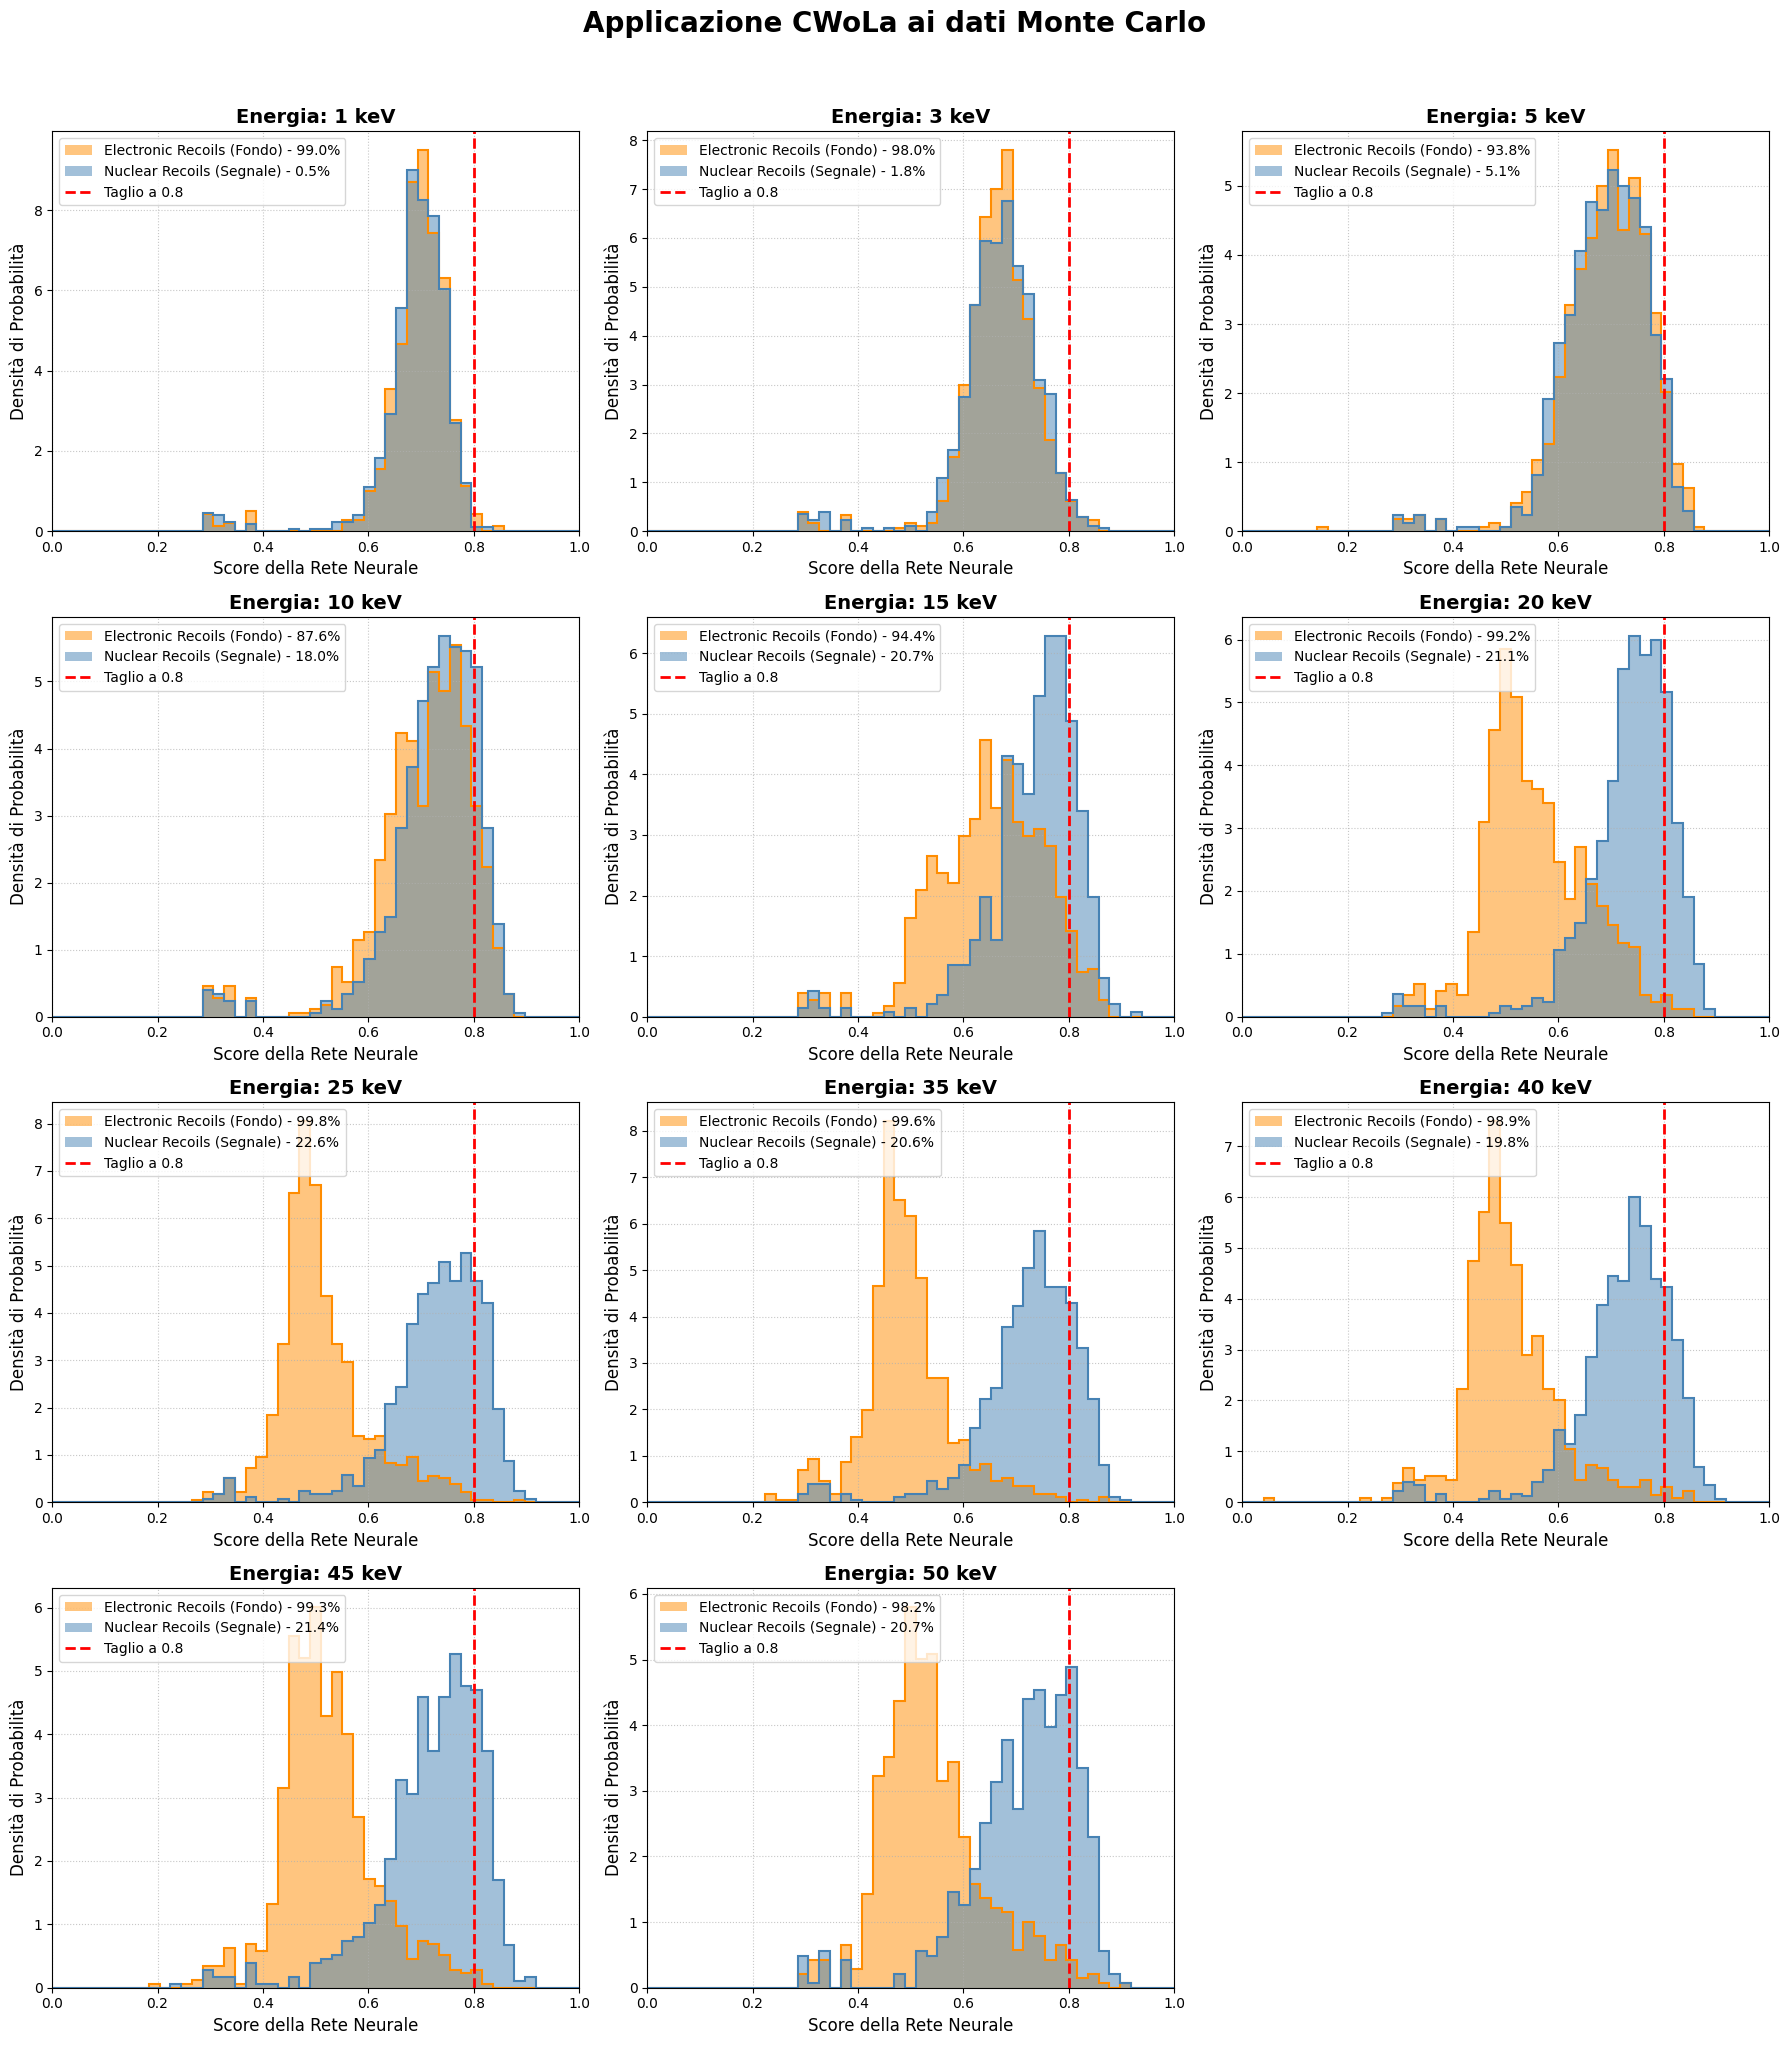

In [22]:
images = "MC_Reconstructed_Dataset\output_images"
energies_list = [1, 3, 5, 10, 15, 20, 25, 35, 40, 45, 50]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = CWolaGNN_Pro(num_node_features=3)

# 3. Carica i pesi dal file .pth
# Usiamo 'map_location' per evitare errori se carichi su CPU un modello addestrato su GPU
weights_path = "best_cwola_weights.pth"
model.load_state_dict(torch.load(weights_path, map_location=device))

# 4. Sposta il modello sul device corretto e impostalo in modalità valutazione (eval)
model = model.to(device)
model.eval()

print("Modello PyTorch caricato con successo!")



# Esecuzione
mc_scores_dict = score_and_plot_energy_scan(
    base_path= images, 
    energies=energies_list, 
    model=model,
    title="Applicazione CWoLa ai dati Monte Carlo"
)